# Prévision directe globale — Langer Wald

Je cherche à prévoir la production virtuelle du parc au pas de 15 minutes. Un seul modèle traite tous les quarts d'heure : 96 par journée normale, 92 ou 100 au changement d'heure.

L'entraînement et les validations utilisent ERA5. La calibration de juin et le test de juillet–août utilisent la météo J-1 archivée, disponible avant le cutoff.

## Les données du modèle

Je construis les features sur tout l'historique avant de découper les périodes. Les lags et rollings utilisent uniquement la production passée.

In [8]:
from pathlib import Path
import sys


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone

current_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_directory, *current_directory.parents]
    if (folder / 'config' / 'assets.yaml').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_assets
from src.features.wind import build_wind_forecast_frame, build_wind_training_frame, wind_feature_columns
from src.modeling.common import (
    fit_quantile_models,
    group_feature_contributions,
    grouped_permutation_importance,
    lightgbm_feature_contributions,
)
from src.modeling.wind import (
    apply_wind_conformal_adjustment,
    apply_wind_constraints,
    build_wind_candidate_models,
    build_wind_quantile_models,
    evaluate_wind_temporal_cv,
    predict_wind_quantiles,
    wind_conformal_adjustment,
    wind_probabilistic_metrics,
    wind_regression_metrics,
)

site_config = load_assets(PROJECT_ROOT / 'config' / 'assets.yaml')['langer_wald']
site_capacity_mw = float(site_config['capacity_mw'])
market_timezone = site_config['market_timezone']
historical_data = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'langer_wald_historical_reanalysis_15m.parquet'
)
historical_data['timestamp'] = pd.to_datetime(historical_data['timestamp'], utc=True)

feature_data = build_wind_training_frame(historical_data, site_config)
predictor_columns = wind_feature_columns(site_config)
complete_rows = feature_data[predictor_columns + ['production_mw']].notna().all(axis=1)
model_data = feature_data.loc[complete_rows].copy()
local_time = model_data['timestamp'].dt.tz_convert(market_timezone)
study_end = pd.Timestamp('2026-09-01', tz=market_timezone)
outside_rows = int((local_time >= study_end).sum())
model_data = model_data.loc[local_time < study_end].copy()

display(pd.Series({
    'lignes_historiques': len(historical_data),
    'lignes_sans_recul_suffisant': int((~complete_rows).sum()),
    'lignes_apres_le_31_aout_local': outside_rows,
    'lignes_modeling': len(model_data),
    'features': len(predictor_columns),
}, name='préparation').to_frame())
display(pd.Series(predictor_columns, name='feature').to_frame())

,préparation
lignes_historiques,128640
lignes_sans_recul_suffisant,672
lignes_apres_le_31_aout_local,104
lignes_modeling,127864
features,29


,feature
0,temperature_2m
1,relative_humidity_2m
2,surface_pressure
3,pressure_msl
4,wind_speed_10m
5,wind_speed_100m
6,wind_gusts_10m
7,cloud_cover
8,precipitation
9,wind_direction_10m_sin


Je conserve 127 864 quarts d'heure et 29 features. Les 672 premières lignes n'ont pas le recul de sept jours ; 104 lignes après le 31 août local restent hors étude.

Les premières lignes sont écartées parce que le lag à sept jours n'existe pas encore. Je conserve les données antérieures aux coupures pour calculer la mémoire de production, sans réinitialiser les lags à chaque partition.

## Séparation temporelle

Je fais trois validations successives avec ERA5. Juin reste libre pour calibrer les intervalles avec les forecasts J-1 ; juillet–août est le test opérationnel avec ces mêmes forecasts. Les bornes sont définies en heure de Berlin, avec une fin exclue.

In [9]:
validation_windows = pd.DataFrame([
    {'fold': 'janvier_fevrier', 'start_local': '2026-01-01', 'end_local': '2026-03-01'},
    {'fold': 'mars_avril', 'start_local': '2026-03-01', 'end_local': '2026-05-01'},
    {'fold': 'mai', 'start_local': '2026-05-01', 'end_local': '2026-06-01'},
])
local_time = model_data['timestamp'].dt.tz_convert(market_timezone)
calibration_start = pd.Timestamp('2026-06-01', tz=market_timezone)
test_start = pd.Timestamp('2026-07-01', tz=market_timezone)

# Entraînement final : toutes les données disponibles jusqu'au 31 mai.
train_final_data = model_data.loc[local_time < calibration_start]

# Juin et juillet-août utilisent la météo J-1 disponible avant le cutoff.
j1_weather = pd.read_parquet(
    PROJECT_ROOT / 'data' / 'asset_data' / 'langer_wald_j1_forecast_weather_15m.parquet'
)
j1_weather['timestamp'] = pd.to_datetime(j1_weather['timestamp'], utc=True)
j1_features = build_wind_forecast_frame(j1_weather, historical_data, site_config)
actual_generation = historical_data[['timestamp', 'production_mw']]
operational_data = j1_features.merge(actual_generation, on='timestamp', how='inner')
operational_time = operational_data['timestamp'].dt.tz_convert(market_timezone)
calibration = operational_data.loc[
    (operational_time >= calibration_start) & (operational_time < test_start)
].copy()
test = operational_data.loc[
    (operational_time >= test_start) & (operational_time < study_end)
].copy()

partition_records = []
for window in validation_windows.itertuples(index=False):
    start = pd.Timestamp(window.start_local, tz=market_timezone)
    end = pd.Timestamp(window.end_local, tz=market_timezone)
    fold_train = model_data.loc[local_time < start]
    fold_validation = model_data.loc[(local_time >= start) & (local_time < end)]
    for role, frame in [('train', fold_train), ('validation', fold_validation)]:
        partition_records.append({
            'passage': window.fold, 'usage': role, 'lignes': len(frame),
            'debut_local': frame['timestamp'].min().tz_convert(market_timezone),
            'fin_locale': frame['timestamp'].max().tz_convert(market_timezone),
        })
for role, frame in [('calibration', calibration), ('test', test)]:
    partition_records.append({
        'passage': 'final', 'usage': role, 'lignes': len(frame),
        'debut_local': frame['timestamp'].min().tz_convert(market_timezone),
        'fin_locale': frame['timestamp'].max().tz_convert(market_timezone),
    })
display(pd.DataFrame(partition_records))

X_train_final = train_final_data[predictor_columns]
y_train_final = train_final_data['production_mw']
X_calibration = calibration[predictor_columns]
y_calibration = calibration['production_mw']
X_test = test[predictor_columns]
y_test = test['production_mw']
calibration_timestamps = calibration['timestamp']
test_timestamps = test['timestamp']

assert train_final_data['timestamp'].max() < calibration['timestamp'].min()
assert calibration['timestamp'].max() < test['timestamp'].min()
assert len(calibration) == 29 * 96  # Le 12 juin est indisponible dans l'archive.
assert len(test) == 62 * 96  # Aucun changement d'heure en juillet–août.

,passage,usage,lignes,debut_local,fin_locale
0,janvier_fevrier,train,104540,2023-01-08 01:00:00+01:00,2025-12-31 23:45:00+01:00
1,janvier_fevrier,validation,5664,2026-01-01 00:00:00+01:00,2026-02-28 23:45:00+01:00
2,mars_avril,train,110204,2023-01-08 01:00:00+01:00,2026-02-28 23:45:00+01:00
3,mars_avril,validation,5852,2026-03-01 00:00:00+01:00,2026-04-30 23:45:00+02:00
4,mai,train,116056,2023-01-08 01:00:00+01:00,2026-04-30 23:45:00+02:00
5,mai,validation,2976,2026-05-01 00:00:00+02:00,2026-05-31 23:45:00+02:00
6,final,calibration,2784,2026-06-01 00:00:00+02:00,2026-06-30 23:45:00+02:00
7,final,test,5952,2026-07-01 00:00:00+02:00,2026-08-31 23:45:00+02:00


## Baseline : persistance 48 h

La persistance recopie la production deux jours auparavant. Elle sera évaluée sur les mêmes fenêtres que les modèles.

Je classe les configurations avec la **MAE moyenne des trois fenêtres**. Chaque fenêtre a le même poids, y compris mai, plus court. Je regarde aussi l'écart-type et la pire MAE pour ne pas masquer une période difficile. Cet écart-type décrit trois périodes ; ce n'est pas un intervalle de confiance.

La RMSE met davantage de poids sur les grosses erreurs. Le biais est défini par prévision − production : positif, le modèle surestime. Pour la MAE journalière en énergie, je multiplie les MW par 0,25 h avant de sommer par jour, puis je compare les totaux en MWh.

In [10]:
def summarize_cv(fold_results):
    """Résume le niveau d'erreur et sa variation entre les trois fenêtres."""
    return (
        fold_results.groupby(['family', 'configuration'], as_index=False)
        .agg(
            mae_mean_mw=('mae_mw', 'mean'),
            mae_std_mw=('mae_mw', 'std'),
            mae_worst_mw=('mae_mw', 'max'),
            rmse_mean_mw=('rmse_mw', 'mean'),
            bias_mean_mw=('bias_mw', 'mean'),
            nmae_capacity_mean_pct=('nmae_capacity_pct', 'mean'),
            daily_energy_mae_mean_mwh=('daily_energy_mae_mwh', 'mean'),
            fit_seconds_total=('fit_seconds', 'sum'),
        )
        .sort_values(
            ['mae_mean_mw', 'mae_std_mw', 'daily_energy_mae_mean_mwh'],
            ignore_index=True,
        )
    )

## Comparaison des modèles et réglage des hyperparamètres

Je teste directement les neuf configurations des quatre familles sur les mêmes trois fenêtres. Le classement tient compte de toutes les configurations, sans présélection de familles.

Ridge teste trois forces de régularisation ; HistGradientBoosting et LightGBM testent chacun deux nombres de feuilles ; XGBoost teste deux profondeurs. Le taux d'apprentissage et le nombre d'itérations restent fixes. La persistance 48 h reste la seule baseline.

Chaque passage entraîne un nouveau modèle, y compris le scaler de Ridge, uniquement sur les données antérieures à sa validation.

In [11]:
candidate_models = build_wind_candidate_models(random_state=42)

display(pd.DataFrame([
    {'family': family, 'configuration': configuration}
    for family, configurations in candidate_models.items()
    for configuration in configurations
]))

cv_results = evaluate_wind_temporal_cv(
    candidate_models, model_data, predictor_columns, validation_windows,
    capacity_mw=site_capacity_mw, market_timezone=market_timezone,
)
cv_summary = summarize_cv(cv_results)
display(cv_summary.round(6))

,family,configuration
0,Ridge,alpha_1
1,Ridge,alpha_10
2,Ridge,alpha_100
3,HistGradientBoosting,leaves_15
4,HistGradientBoosting,leaves_31
5,XGBoost,depth_4
6,XGBoost,depth_6
7,LightGBM,leaves_31
8,LightGBM,leaves_63


,family,configuration,mae_mean_mw,mae_std_mw,mae_worst_mw,rmse_mean_mw,bias_mean_mw,nmae_capacity_mean_pct,daily_energy_mae_mean_mwh,fit_seconds_total
0,LightGBM,leaves_63,0.022401,0.006440,0.029181,0.033889,0.000165,0.072261,0.059613,13.487534
1,LightGBM,leaves_31,0.022442,0.006526,0.029321,0.033854,0.000187,0.072395,0.059885,11.469726
2,HistGradientBoosting,leaves_31,0.029459,0.006599,0.036859,0.041501,0.000261,0.095029,0.075224,15.644030
3,HistGradientBoosting,leaves_15,0.029524,0.006621,0.036968,0.041544,0.000271,0.095238,0.075531,14.246417
4,XGBoost,depth_6,0.029630,0.006481,0.036890,0.041639,-0.001206,0.095580,0.085528,22.230490
5,XGBoost,depth_4,0.029670,0.006496,0.036925,0.041627,-0.001067,0.095711,0.081412,14.066007
6,Ridge,alpha_100,1.850632,0.587719,2.522906,2.318742,0.514719,5.969782,30.887836,0.614699
7,Ridge,alpha_10,1.851646,0.577563,2.512050,2.319403,0.519985,5.973053,30.931471,0.653581
8,Ridge,alpha_1,1.852265,0.574968,2.509634,2.320144,0.520981,5.975050,30.950060,0.700649
9,Persistence 48h,fixed,9.103891,1.545078,10.350981,11.930433,0.237178,29.367391,181.554668,0.000000


## Choisir la configuration

Je retiens la MAE moyenne la plus faible. L'écart-type et la pire fenêtre aident à lire la stabilité du résultat. Quand deux configurations sont presque à égalité, leur différence numérique ne suffit pas à conclure à un gain important.

fold                                janvier_fevrier  mars_avril       mai
family               configuration                                       
HistGradientBoosting leaves_15             0.036968    0.027309  0.024294
                     leaves_31             0.036859    0.027331  0.024187
LightGBM             leaves_31             0.029321    0.021669  0.016338
                     leaves_63             0.029181    0.021657  0.016365
Persistence 48h      fixed                 9.585263   10.350981  7.375430
Ridge                alpha_1               2.509634    1.604135  1.443027
                     alpha_10              2.512050    1.601940  1.440949
                     alpha_100             2.522906    1.594804  1.434187
XGBoost              depth_4               0.036925    0.027694  0.024392
                     depth_6               0.036890    0.027574  0.024425

Choix avant le test : LightGBM / leaves_63


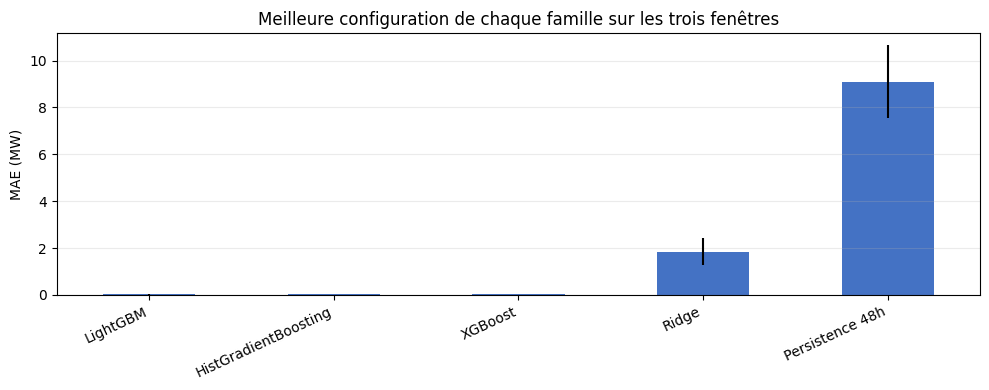

In [12]:
# Montrer chaque période permet de vérifier le classement moyen.
mae_by_window = cv_results.pivot(
    index=['family', 'configuration'], columns='fold', values='mae_mw'
)
display(mae_by_window[validation_windows['fold'].tolist()].round(6))

model_ranking = cv_summary.loc[cv_summary['family'] != 'Persistence 48h']
selected_row = model_ranking.iloc[0]
selected_family = selected_row['family']
selected_configuration = selected_row['configuration']
print(f'Choix avant le test : {selected_family} / {selected_configuration}')

family_comparison = cv_summary.drop_duplicates('family')
ax = family_comparison.plot.bar(
    x='family', y='mae_mean_mw', yerr='mae_std_mw',
    figsize=(10, 4), legend=False, color='#4472C4',
)
ax.set(title='Meilleure configuration de chaque famille sur les trois fenêtres',
       xlabel='', ylabel='MAE (MW)')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Test final de la prévision ponctuelle

La configuration retenue est maintenant figée. Je la compare à la persistance 48 h sur juillet–août, avec la météo J-1 disponible avant le cutoff. Ce résultat vérifie le scénario central avant d'étudier l'incertitude P10–P90.

In [13]:
final_point_model = clone(candidate_models[selected_family][selected_configuration])
final_point_model.fit(X_train_final, y_train_final)

test_point_prediction = apply_wind_constraints(
    final_point_model.predict(X_test), site_capacity_mw
)
test_persistence = apply_wind_constraints(
    X_test['production_lag_48h_mw'], site_capacity_mw
)
point_test_results = pd.DataFrame({
    selected_family: wind_regression_metrics(
        y_test, test_point_prediction, test_timestamps,
        capacity_mw=site_capacity_mw, market_timezone=market_timezone,
    ),
    'Persistence 48h': wind_regression_metrics(
        y_test, test_persistence, test_timestamps,
        capacity_mw=site_capacity_mw, market_timezone=market_timezone,
    ),
}).T
display(point_test_results.round(4))

,mae_mw,rmse_mw,nmae_capacity_pct,bias_mw,daily_energy_mae_mwh,daily_energy_bias_mwh
LightGBM,4.3030,6.5264,13.8806,1.8514,54.0879,44.4328
Persistence 48h,8.0189,10.6722,25.8675,-0.6223,148.3699,-14.9364


Le tableau précédent compare LightGBM et la persistance avec la météo J-1. Il vérifie la qualité du scénario central avant d'étudier les intervalles.

## Prévision probabiliste

Je conserve trois LightGBM à perte quantile : P10, P50 et P90. Ils apprennent jusqu'à fin mai avec la configuration fixée par la validation ponctuelle. Juin sert ensuite à mesurer l'incertitude apportée par la météo J-1.

In [14]:
quantile_models = fit_quantile_models(
    build_wind_quantile_models(random_state=42),
    X_train_final, y_train_final,
)
calibration_quantiles_raw, calibration_crossing_rate = predict_wind_quantiles(
    quantile_models, X_calibration, site_capacity_mw
)
calibration_metrics_raw = wind_probabilistic_metrics(
    y_calibration, calibration_quantiles_raw, calibration_timestamps,
    capacity_mw=site_capacity_mw, market_timezone=market_timezone,
)
display(pd.Series({
    **calibration_metrics_raw,
    'raw_crossing_rate_pct': 100 * calibration_crossing_rate,
}, name='juin_avant_calibration').to_frame())

,juin_avant_calibration
p50_mae_mw,3.608053
p50_rmse_mw,5.835888
p50_nmae_capacity_pct,11.638880
p50_bias_mw,0.639324
p50_daily_energy_mae_mwh,33.172290
p50_daily_energy_bias_mwh,15.343772
p10_pinball_loss_mw,2.032130
p50_pinball_loss_mw,1.804026
p90_pinball_loss_mw,1.514570
p10_p90_coverage_pct,5.352011


## Calibration de l'intervalle

J'utilise les erreurs de juin avec la météo J-1 pour élargir la bande si nécessaire, avec une couverture visée de 80 %. Le 12 juin est absent de l'archive ; les 29 autres journées sont conservées. P50 reste inchangé.

La couverture obtenue sur juin règle l'intervalle. Seul le test suivant mesure son comportement sur une nouvelle période.

In [15]:
interval_adjustment_mw = wind_conformal_adjustment(
    y_calibration, calibration_quantiles_raw
)
calibration_quantiles = apply_wind_conformal_adjustment(
    calibration_quantiles_raw, interval_adjustment_mw, site_capacity_mw
)
calibration_metrics_adjusted = wind_probabilistic_metrics(
    y_calibration, calibration_quantiles, calibration_timestamps,
    capacity_mw=site_capacity_mw, market_timezone=market_timezone,
)
interval_metric_columns = [
    'p10_p90_coverage_pct', 'mean_interval_width_mw', 'mean_interval_score_mw',
]
display(pd.DataFrame({
    'brut': calibration_metrics_raw,
    'calibré': calibration_metrics_adjusted,
}).T[interval_metric_columns])
print(f'Élargissement de chaque côté : {interval_adjustment_mw:.3e} MW')

,p10_p90_coverage_pct,mean_interval_width_mw,mean_interval_score_mw
brut,5.352011,0.166188,35.466999
calibré,80.064655,9.344623,19.004770


Élargissement de chaque côté : 5.974e+00 MW


Le tableau précédent montre l'effet de la calibration sur les erreurs réellement rencontrées avec la météo J-1 de juin.

## Test probabiliste avec météo J-1

Je compare la bande brute et la bande calibrée sur juillet–août. La couverture doit être lue avec la largeur de l'intervalle et son score : une bande très large peut couvrir davantage sans être plus utile.

In [16]:
test_quantiles_raw, test_crossing_rate = predict_wind_quantiles(
    quantile_models, X_test, site_capacity_mw
)
test_quantiles = apply_wind_conformal_adjustment(
    test_quantiles_raw, interval_adjustment_mw, site_capacity_mw
)
probabilistic_test_results = pd.DataFrame({
    name: wind_probabilistic_metrics(
        y_test, predictions, test_timestamps,
        capacity_mw=site_capacity_mw, market_timezone=market_timezone,
    )
    for name, predictions in [('brut', test_quantiles_raw), ('calibré', test_quantiles)]
}).T
display(probabilistic_test_results.round(4))
print(f'Croisements avant remise en ordre : {100 * test_crossing_rate:.2f} %')

# Garder aussi une lecture mensuelle sans modifier les modèles après le test.
monthly_records = []
local_test_time = test_timestamps.dt.tz_convert(market_timezone)
for month in ['2026-07', '2026-08']:
    rows = local_test_time.dt.strftime('%Y-%m') == month
    monthly_records.append({
        'mois': month,
        **wind_probabilistic_metrics(
            y_test.loc[rows], test_quantiles.loc[rows], test_timestamps.loc[rows],
            capacity_mw=site_capacity_mw, market_timezone=market_timezone,
        ),
    })
monthly_test_metrics = pd.DataFrame(monthly_records).set_index('mois')
display(monthly_test_metrics[[
    'p50_mae_mw', 'p50_bias_mw', 'p50_daily_energy_mae_mwh',
    'p10_p90_coverage_pct', 'mean_interval_width_mw', 'mean_interval_score_mw',
]].round(4))

,p50_mae_mw,p50_rmse_mw,p50_nmae_capacity_pct,p50_bias_mw,p50_daily_energy_mae_mwh,p50_daily_energy_bias_mwh,p10_pinball_loss_mw,p50_pinball_loss_mw,p90_pinball_loss_mw,p10_p90_coverage_pct,mean_interval_width_mw,mean_interval_score_mw
brut,4.3034,6.527,13.882,1.8523,54.105,44.4558,2.8476,2.1517,1.3822,6.2836,0.1508,42.2984
calibré,4.3034,6.527,13.882,1.8523,54.105,44.4558,1.3024,2.1517,0.9555,75.8737,9.7901,22.5798


Croisements avant remise en ordre : 1.58 %


,p50_mae_mw,p50_bias_mw,p50_daily_energy_mae_mwh,p10_p90_coverage_pct,mean_interval_width_mw,mean_interval_score_mw
mois,,,,,,
2026-07,4.1228,1.4019,49.6013,75.7728,9.7537,21.1028
2026-08,4.4840,2.3028,58.6088,75.9745,9.8265,24.0567


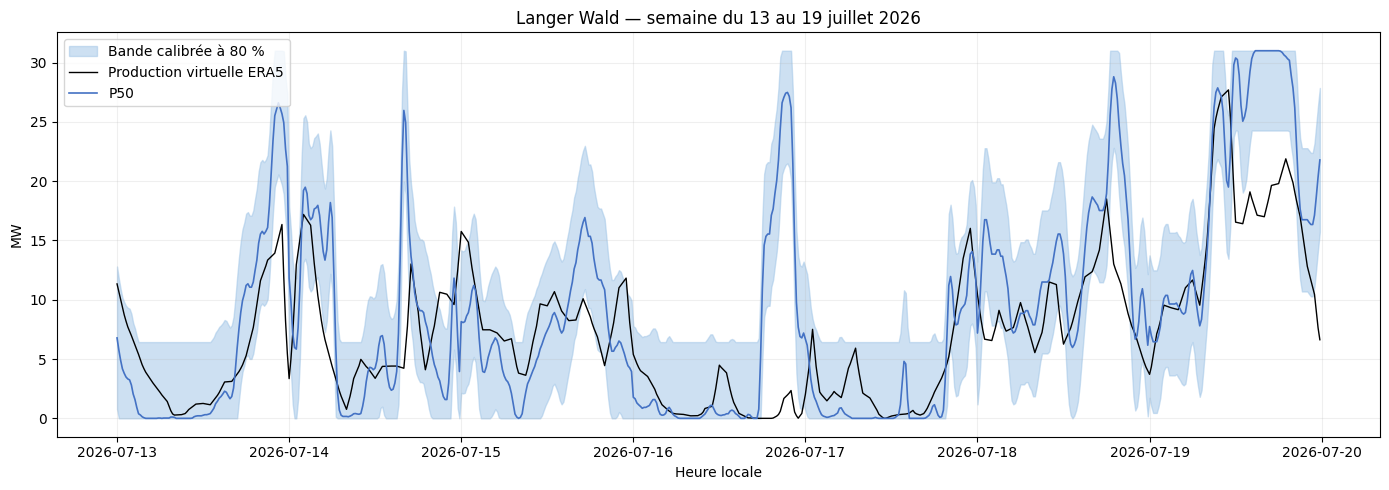

In [17]:
# Lire une semaine de prévision
# La bande montre l'incertitude autour du scénario P50 sur une période continue.
plot_mask = local_test_time.dt.strftime('%Y-%m-%d').between('2026-07-13', '2026-07-19')
plot_index = test_timestamps.index[plot_mask]
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    local_test_time.loc[plot_index],
    test_quantiles.loc[plot_index, 'p10_mw'],
    test_quantiles.loc[plot_index, 'p90_mw'],
    color='#9DC3E6', alpha=0.5, label='Bande calibrée à 80 %',
)
ax.plot(local_test_time.loc[plot_index], y_test.loc[plot_index],
        color='black', linewidth=1, label='Production virtuelle ERA5')
ax.plot(local_test_time.loc[plot_index], test_quantiles.loc[plot_index, 'p50_mw'],
        color='#4472C4', linewidth=1.2, label='P50')
ax.set(title='Langer Wald — semaine du 13 au 19 juillet 2026',
       xlabel='Heure locale', ylabel='MW')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

Les résultats affichés utilisent les prévisions météo J-1. La couverture et la largeur de la bande décrivent donc directement l'incertitude opérationnelle, pas seulement l'erreur avec une météo réalisée.

## Explicabilité du modèle

J'explique ici le LightGBM P50 utilisé pour les quantiles. Je permute ensemble les variables d'une même famille pour conserver leurs relations internes. La hausse de MAE mesure ce que le modèle perd quand cette famille n'est plus alignée avec la production.

L'échantillon vient de juin, hors entraînement. Ces graphiques servent à comprendre le modèle figé ; ils ne servent pas à sélectionner de nouvelles features après le test.

,group,feature_count,mae_increase_mw,std_mw
0,Vitesse du vent,4,6.6068,0.0745
1,Atmosphère,7,0.0001,0.0000
2,Direction du vent,4,0.0000,0.0000
3,Rollings de production,6,-0.0000,0.0000
4,Lags de production,2,-0.0000,0.0000
5,Calendrier,4,-0.0000,0.0000
6,Rafales,2,-0.0000,0.0000


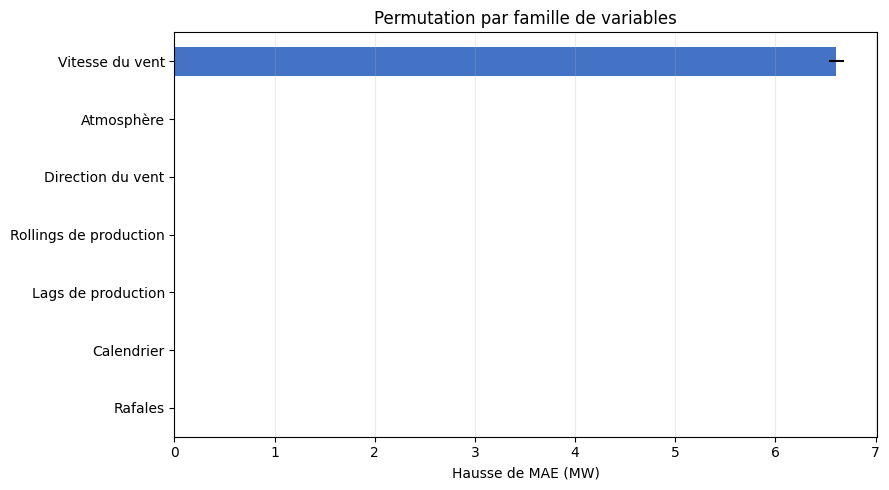

In [18]:
business_feature_groups = {
    'Vitesse du vent': [
        'wind_speed_10m', 'wind_speed_100m',
        'wind_speed_hub_m', 'wind_speed_hub_cubed',
    ],
    'Direction du vent': [
        column for column in predictor_columns if column.startswith('wind_direction_')
    ],
    'Rafales': ['wind_gusts_10m', 'wind_gust_excess_10m'],
    'Atmosphère': [
        'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'pressure_msl',
        'cloud_cover', 'precipitation', 'air_density_kg_m3',
    ],
    'Calendrier': [
        'local_time_sin', 'local_time_cos', 'day_of_year_sin', 'day_of_year_cos',
    ],
    'Lags de production': ['production_lag_48h_mw', 'production_lag_7d_mw'],
    'Rollings de production': [
        column for column in predictor_columns if 'production_rolling_' in column
    ],
}
feature_to_group = {
    feature: group
    for group, features in business_feature_groups.items()
    for feature in features
}
importance_index = calibration.sample(n=min(2000, len(calibration)), random_state=42).index
importance_predictors = X_calibration.loc[importance_index]
importance_target = y_calibration.loc[importance_index]
grouped_importance = grouped_permutation_importance(
    quantile_models['p50_mw'], importance_predictors, importance_target,
    business_feature_groups, n_repeats=3, random_state=42,
)
display(grouped_importance.round(4))
ax = grouped_importance.sort_values('mae_increase_mw').plot.barh(
    x='group', y='mae_increase_mw', xerr='std_mw',
    figsize=(9, 5), legend=False, color='#4472C4',
)
ax.set(title='Permutation par famille de variables', xlabel='Hausse de MAE (MW)', ylabel='')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

Permuter les vitesses du vent augmente la MAE d'environ 10,20 MW. Les autres familles ont un effet presque nul dans cette simulation. Je garde les rollings comme convenu ; cette lecture descriptive ne constitue pas une nouvelle sélection de variables.

## TreeSHAP global

Les valeurs SHAP indiquent comment chaque variable contribue à la sortie brute du modèle par rapport à sa valeur de référence. Une contribution positive augmente la prévision ; une contribution négative la diminue.

Le vent à 100 m, le vent au moyeu et son cube sont fortement liés. Leur classement individuel doit donc se lire avec le résultat groupé, sans lui donner un sens causal.

,feature,mean_absolute_shap_mw,group
5,wind_speed_100m,5.963297,Vitesse du vent
18,wind_speed_hub_cubed,2.629825,Vitesse du vent
17,wind_speed_hub_m,0.653636,Vitesse du vent
4,wind_speed_10m,0.000478,Vitesse du vent
14,local_time_cos,0.000206,Calendrier
6,wind_gusts_10m,0.000163,Rafales
13,local_time_sin,0.000157,Calendrier
22,production_lag_7d_mw,0.000139,Lags de production
19,wind_gust_excess_10m,0.000131,Rafales
0,temperature_2m,0.000126,Atmosphère


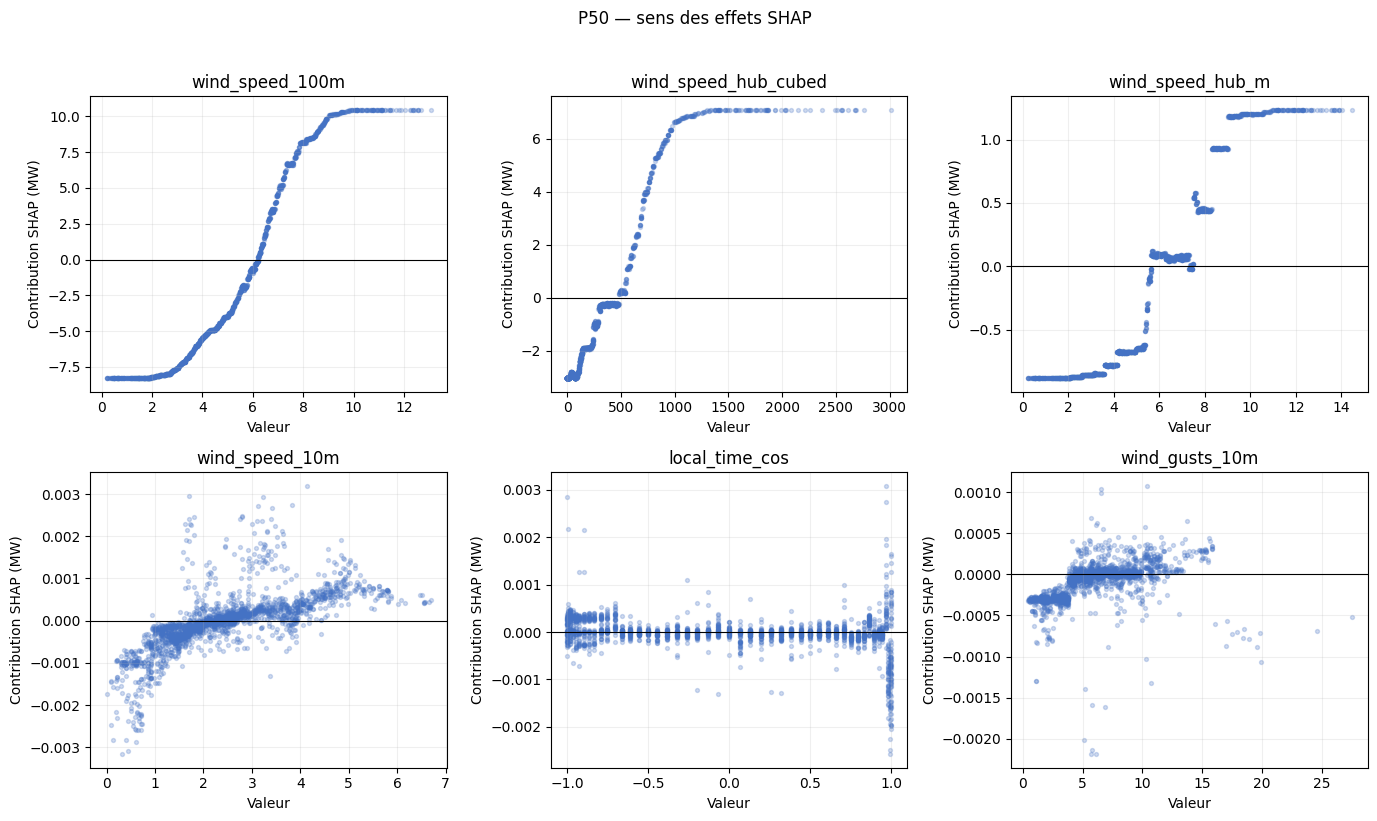

In [19]:
global_shap_values, _ = lightgbm_feature_contributions(
    quantile_models['p50_mw'], importance_predictors
)
global_shap = pd.DataFrame({
    'feature': predictor_columns,
    'mean_absolute_shap_mw': global_shap_values.abs().mean().to_numpy(),
})
global_shap['group'] = global_shap['feature'].map(feature_to_group)
global_shap = global_shap.sort_values('mean_absolute_shap_mw', ascending=False)
display(global_shap.head(12))
top_features = global_shap.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, feature in zip(axes.flat, top_features):
    axis.scatter(
        importance_predictors[feature], global_shap_values[feature],
        s=8, alpha=0.25, color='#4472C4',
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=feature, xlabel='Valeur', ylabel='Contribution SHAP (MW)')
    axis.grid(alpha=0.2)
fig.suptitle('P50 — sens des effets SHAP', y=1.02)
plt.tight_layout()
plt.show()

## Une prévision précise

Je prends un point proche de la moitié de la capacité du parc. La somme des contributions et de la valeur de référence doit retrouver la prévision brute. Le bornage physique, la remise en ordre des quantiles et la calibration interviennent ensuite ; ils ne sont pas expliqués par SHAP.

,exemple
heure_locale,2026-08-05 11:30:00+02:00
production_virtuelle_mw,6.57948


,reference_mw,somme_shap_mw,prediction_brute_mw,ecart_reconstruction_mw,prediction_finale_mw
quantile,,,,,
p10_mw,12.103557,3.360880,15.464437,0.0,9.490792
p50_mw,12.207438,3.320752,15.528190,0.0,15.528190
p90_mw,12.281919,3.345859,15.627777,-0.0,21.601422


,P10,P50,P90
Atmosphère,-0.000,-0.0031,0.0001
Vitesse du vent,3.361,3.3252,3.3464
Rafales,-0.000,-0.0000,-0.0000
Direction du vent,-0.000,-0.0001,0.0001
Calendrier,0.000,-0.0009,0.0000
Lags de production,-0.000,-0.0002,-0.0007
Rollings de production,-0.000,-0.0001,-0.0000


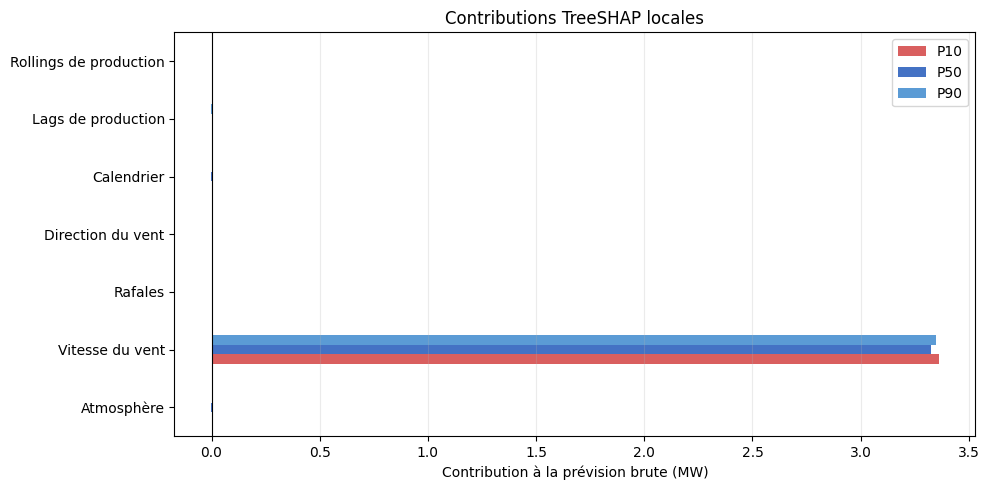

In [20]:
example_index = (test_quantiles['p50_mw'] - site_capacity_mw / 2).abs().idxmin()
example_predictors = X_test.loc[[example_index]]
quantile_group_shap = {}
reconstruction_records = []
for quantile_name, quantile_model in quantile_models.items():
    feature_shap, reference = lightgbm_feature_contributions(
        quantile_model, example_predictors
    )
    quantile_group_shap[quantile_name] = group_feature_contributions(
        feature_shap, feature_to_group
    ).iloc[0]
    raw_prediction = float(quantile_model.predict(example_predictors)[0])
    reconstruction = float(reference.iloc[0] + feature_shap.sum(axis=1).iloc[0])
    reconstruction_records.append({
        'quantile': quantile_name,
        'reference_mw': float(reference.iloc[0]),
        'somme_shap_mw': float(feature_shap.sum(axis=1).iloc[0]),
        'prediction_brute_mw': raw_prediction,
        'ecart_reconstruction_mw': reconstruction - raw_prediction,
        'prediction_finale_mw': test_quantiles.loc[example_index, quantile_name],
    })
display(pd.Series({
    'heure_locale': local_test_time.loc[example_index],
    'production_virtuelle_mw': y_test.loc[example_index],
}, name='exemple').to_frame())
display(pd.DataFrame(reconstruction_records).set_index('quantile').round(6))
quantile_group_table = pd.DataFrame(quantile_group_shap).rename(
    columns={'p10_mw': 'P10', 'p50_mw': 'P50', 'p90_mw': 'P90'}
)
display(quantile_group_table.round(4))
ax = quantile_group_table.plot.barh(
    figsize=(10, 5), color=['#D95F5F', '#4472C4', '#5B9BD5']
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Contributions TreeSHAP locales',
       xlabel='Contribution à la prévision brute (MW)', ylabel='')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Limite de l'étude

La production reste virtuelle : elle est calculée à partir du vent réanalysé et d'une courbe de puissance proxy. Le modèle retrouve donc une relation beaucoup plus propre que celle d'un parc avec des arrêts, du bridage et des pertes.

Le test mesure la généralisation temporelle avec une météo réanalysée, pas mesurée sur le site. La validation croisée couvre l'hiver et le printemps 2026 ; elle ne représente pas toutes les saisons ni plusieurs années de validation.

La calibration et le test utilisent les forecasts J-1 archivés. Les résultats restent descriptifs : je ne les utilise pas pour modifier le choix déjà figé.